In [84]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

# Models
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [85]:
# Load datasets
train = pd.read_csv("ehsi_train_data.csv")
items = pd.read_csv("items.csv")
holidays = pd.read_csv("holidays_events.csv")

# Preview
print(train.head())
print(items.head())
print(holidays.head())

         id        date  store_nbr  item_nbr  unit_sales  onpromotion
0  32571854  2014-10-07         51   1121513         5.0        False
1  31317013  2014-09-20          6   1279049         1.0        False
2  36872935  2014-12-07         48   1239906        39.0        False
3  28537288  2014-08-04         46   1242666        11.0        False
4  33295204  2014-10-18         18   1089046         1.0        False
   item_nbr        family  class  perishable
0     96995     GROCERY I   1093           0
1     99197     GROCERY I   1067           0
2    103501      CLEANING   3008           0
3    103520     GROCERY I   1028           0
4    103665  BREAD/BAKERY   2712           1
         date     type    locale locale_name                    description  \
0  2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1  2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2  2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuen

In [86]:
# Data Cleaning
# Convert Date Columns

train['date'] = pd.to_datetime(train['date'])
holidays['date'] = pd.to_datetime(holidays['date'])


In [87]:
# Handle boolean column

train['onpromotion'] = train['onpromotion'].fillna(False).astype(int)

In [88]:
# Transfer Holiday Types

# holiday, event, additional, bridge → "holiday"
# transfer, work day → "work day"

def categorize_holiday(x):
    if x in ['Holiday', 'Event', 'Additional', 'Bridge']:
        return 'holiday'
    elif x in ['Transfer', 'Work Day']:
        return 'work day'
    else:
        return 'work day'  # fallback

holidays['holiday_type'] = holidays['type'].apply(categorize_holiday)

In [89]:
# Merge Datasets

# Merge Train + Items (on item_nbr)

train_items = pd.merge(train, items, 
                       on='item_nbr', how='inner')

# Merge with Holidays (LEFT JOIN to keep all days)
# Non-matching dates → must be "work day"

data = pd.merge(train_items, holidays[['date', 'holiday_type']], 
                on='date', how='left')

# Fill missing days as "work day"
data['holiday_type'] = data['holiday_type'].fillna('work day')


In [90]:
# Basick Check
print(data.head())
print(data['holiday_type'].value_counts())

         id       date  store_nbr  item_nbr  unit_sales  onpromotion  \
0  32571854 2014-10-07         51   1121513         5.0            0   
1  31317013 2014-09-20          6   1279049         1.0            0   
2  36872935 2014-12-07         48   1239906        39.0            0   
3  28537288 2014-08-04         46   1242666        11.0            0   
4  33295204 2014-10-18         18   1089046         1.0            0   

         family  class  perishable holiday_type  
0      CLEANING   3020           0      holiday  
1  BREAD/BAKERY   2708           1     work day  
2         DAIRY   2172           1     work day  
3     GROCERY I   1094           0     work day  
4      CLEANING   3020           0     work day  
holiday_type
work day    17556168
holiday      3660404
Name: count, dtype: int64


#### EDA

onpromotion
0     8.099590
1    13.413814
Name: unit_sales, dtype: float64


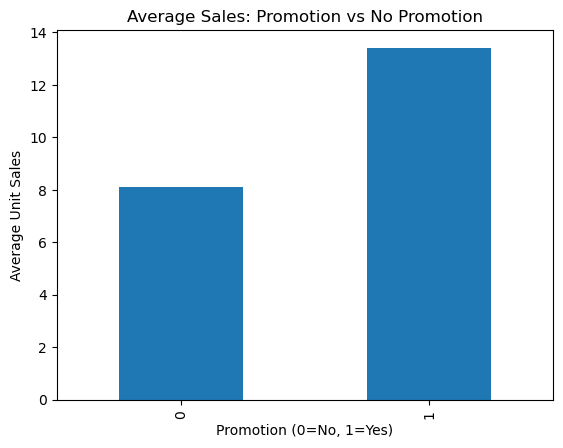

In [91]:
# Average sales with or without promotion

promo_sales = data.groupby('onpromotion')['unit_sales'].mean()

print(promo_sales)

promo_sales.plot(kind='bar')
plt.title("Average Sales: Promotion vs No Promotion")
plt.xlabel("Promotion (0=No, 1=Yes)")
plt.ylabel("Average Unit Sales")
plt.show()

holiday_type
holiday     8.954277
work day    8.405445
Name: unit_sales, dtype: float64


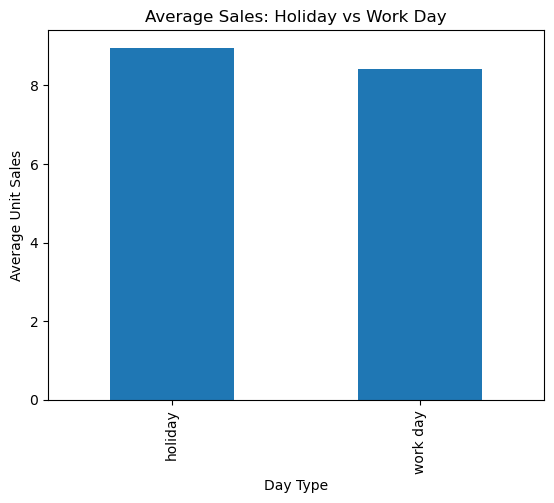

In [92]:
# Average sales on holiday & workday

holiday_sales = data.groupby('holiday_type')['unit_sales'].mean()

print(holiday_sales)

holiday_sales.plot(kind='bar')
plt.title("Average Sales: Holiday vs Work Day")
plt.xlabel("Day Type")
plt.ylabel("Average Unit Sales")
plt.show()

perishable
0     7.667391
1    10.908221
Name: unit_sales, dtype: float64


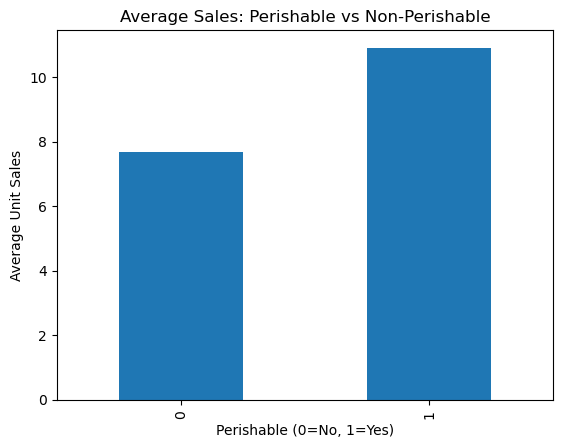

In [93]:
# Average Sales on Perishable vs Non-Perishable

perishable_sales = data.groupby('perishable')['unit_sales'].mean()

print(perishable_sales)

perishable_sales.plot(kind='bar')
plt.title("Average Sales: Perishable vs Non-Perishable")
plt.xlabel("Perishable (0=No, 1=Yes)")
plt.ylabel("Average Unit Sales")
plt.show()

onpromotion          0          1
holiday_type                     
holiday       8.579223  13.245258
work day      8.000242  13.451819


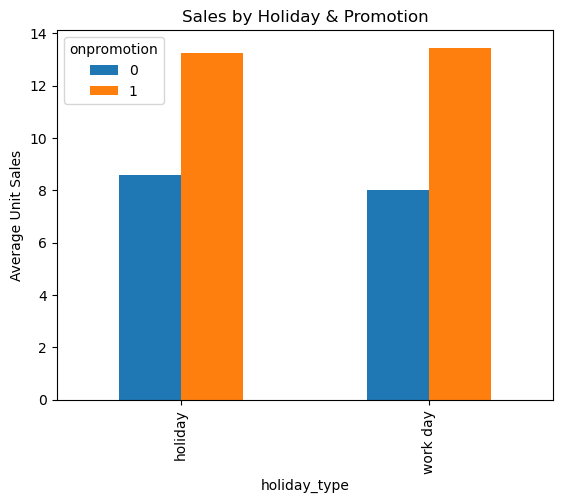

In [94]:
# Sales by Holiday & Promotion

combo1 = data.groupby(['holiday_type', 'onpromotion'])['unit_sales'].mean().unstack()

print(combo1)

combo1.plot(kind='bar')
plt.title("Sales by Holiday & Promotion")
plt.ylabel("Average Unit Sales")
plt.show()

onpromotion          0          1
perishable                       
0             7.347259  13.122944
1            10.469928  13.764231


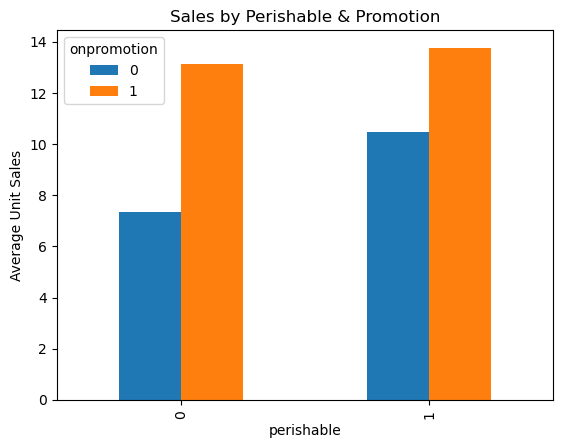

In [95]:
# Sales by Perishable & Promotion

combo2 = data.groupby(['perishable', 'onpromotion'])['unit_sales'].mean().unstack()

print(combo2)

combo2.plot(kind='bar')
plt.title("Sales by Perishable & Promotion")
plt.ylabel("Average Unit Sales")
plt.show()

In [96]:
combo3 = data.groupby(['holiday_type', 'perishable', 'onpromotion'])['unit_sales'].mean()

print(combo3)

holiday_type  perishable  onpromotion
holiday       0           0               7.857932
                          1              12.918780
              1           0              10.838693
                          1              13.685702
work day      0           0               7.241660
                          1              13.171889
              1           0              10.393140
                          1              13.780622
Name: unit_sales, dtype: float64


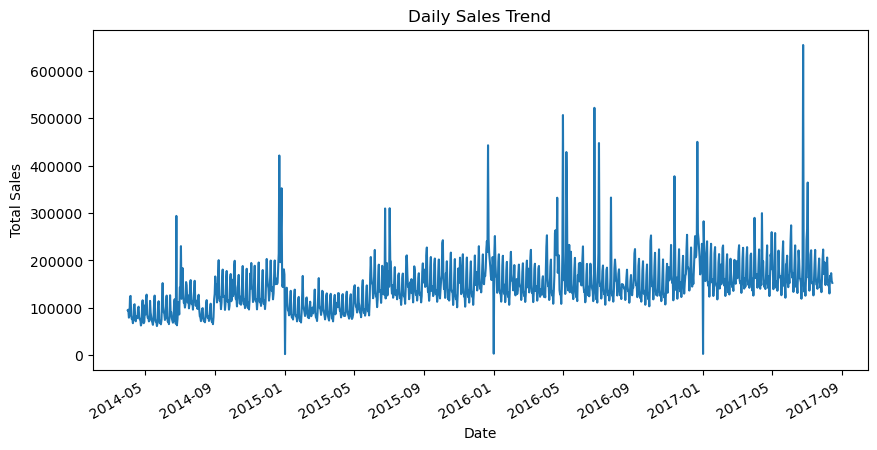

In [97]:
# Trend
daily_sales = data.groupby('date')['unit_sales'].sum()

daily_sales.plot(figsize=(10,5))
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

#### Feature Engineering

In [98]:

family_df = (data.groupby(['date', 'family', 'holiday_type'])
             .agg({
                 'unit_sales': 'sum',
                 'onpromotion': 'mean',
                 'perishable': 'mean'
             })
             .reset_index())

In [99]:
family_df['day'] = family_df['date'].dt.day
family_df['month'] = family_df['date'].dt.month
family_df['dayofweek'] = family_df['date'].dt.dayofweek
family_df['is_weekend'] = family_df['dayofweek'].isin([5,6]).astype(int)

In [100]:
family_df = family_df.sort_values(['family', 'date'])

family_df['lag_7'] = family_df.groupby('family')['unit_sales'].shift(7)
family_df['lag_14'] = family_df.groupby('family')['unit_sales'].shift(14)

family_df['rolling_7'] = family_df.groupby('family')['unit_sales'].shift(1).rolling(7).mean()

In [101]:
# Train-test Split
family_df = family_df.sort_values('date')

split_index = int(len(family_df) * 0.7)

train_df = family_df.iloc[:split_index]
test_df  = family_df.iloc[split_index:]

X_train = train_df.drop(columns=['unit_sales', 'date'])
y_train = train_df['unit_sales']

X_test = test_df.drop(columns=['unit_sales', 'date'])
y_test = test_df['unit_sales']

In [102]:
# Pipelines

categorical_cols = ['family', 'holiday_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ],
    remainder='passthrough'
)

In [103]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    ))
])

In [104]:
# Train
pipeline.fit(X_train, y_train)

# -----------------------------
# 8. EVALUATION
# -----------------------------
preds = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 3108.788096099165
MAE: 716.3193795430686
R2: 0.9341190516292234


In [105]:
def forecast_family(model, df, days):
    df = df.copy()
    forecasts = []

    families = df['family'].unique()

    for f in families:
        group = df[df['family'] == f].sort_values('date').copy()

        for _ in range(days):
            last_row = group.iloc[-1:].copy()
            next_date = last_row['date'].values[0] + np.timedelta64(1, 'D')

            new_row = last_row.copy()
            new_row['date'] = next_date

            dt = pd.to_datetime(next_date)
            new_row['day'] = dt.day
            new_row['month'] = dt.month
            new_row['dayofweek'] = dt.dayofweek
            new_row['is_weekend'] = int(dt.dayofweek in [5,6])

            # Lag features
            new_row['lag_7'] = group['unit_sales'].iloc[-7]
            new_row['lag_14'] = group['unit_sales'].iloc[-14]
            new_row['rolling_7'] = group['unit_sales'].iloc[-7:].mean()

            X_new = new_row.drop(columns=['unit_sales', 'date'])
            # Ensure it's 2D DataFrame
            X_new = pd.DataFrame(X_new)
            new_row['unit_sales'] = model.predict(X_new)

            group = pd.concat([group, new_row], ignore_index=True)
            forecasts.append(new_row)

    return pd.concat(forecasts)

In [106]:
forecast_7 = forecast_family(pipeline, family_df, 7)
forecast_14 = forecast_family(pipeline, family_df, 14)
forecast_30 = forecast_family(pipeline, family_df, 30)

In [107]:
from joblib import dump

dump(pipeline, "sales_pipeline.pkl")

['sales_pipeline.pkl']

In [108]:
family_df.to_csv("family_df.csv", index=False)